# Customer Churn Prediction using Agglomerative Clustering

This notebook demonstrates a customer churn prediction approach using Agglomerative Clustering. We will load customer data, preprocess relevant features, apply an unsupervised clustering algorithm, visualize the results using PCA, and evaluate the clustering performance.

## 1. Setup and Imports

This section imports all necessary libraries for data manipulation, scaling, clustering, dimensionality reduction, and visualization.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from google.colab import files
from sklearn.impute import SimpleImputer
import numpy as np

## 2. Data Loading and Preprocessing

We will load the `ChurnPrediction.csv` dataset, inspect its structure, select features relevant for clustering, handle missing values, and scale the data to prepare it for the clustering algorithm.

In [ ]:

# Load the dataset
df = pd.read_csv('ChurnPrediction.csv')

# Display basic information
print(df.head())
print(df.info())

# Select relevant features for clustering
features = df[['MonthlyCharges', 'TotalCharges', 'PaymentMethod', 'PaperlessBilling', 'MultipleLines']]

# Replace empty strings or strings with spaces with NaN
features.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Convert the columns to numeric type, coercing errors to NaN
features = features.apply(pd.to_numeric, errors='coerce')

# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_imputed)


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

<ipython-input-7-6623b9a9a1d4>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.replace(r'^\s*$', np.nan, regex=True, inplace=True)
/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['PaymentMethod' 'PaperlessBilling' 'MultipleLines']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


### 2.1 Feature Selection

We select a subset of features that are relevant for identifying customer segments. For this clustering task, we focus on `MonthlyCharges`, `TotalCharges`, `PaymentMethod`, `PaperlessBilling`, and `MultipleLines`. Note that categorical features will be converted to numeric during preprocessing.

In [ ]:
features = df[['MonthlyCharges', 'TotalCharges', 'PaymentMethod', 'PaperlessBilling', 'MultipleLines']]
display(features.head())

### 2.2 Handle Missing Values and Convert Data Types

`TotalCharges` is initially an object type and can contain empty strings, which are treated as NaNs. We convert these to numeric, coercing errors, and then impute any missing values (including those from categorical features that became NaN after `pd.to_numeric`) using the mean strategy.

In [ ]:
# Replace empty strings or strings with spaces with NaN
features.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Convert the columns to numeric type, coercing errors to NaN
# Note: This will turn non-numeric categorical values into NaN for 'PaymentMethod', 'PaperlessBilling', 'MultipleLines'
features_numeric = features.apply(pd.to_numeric, errors='coerce')

# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features_numeric)

# Convert back to DataFrame for clarity (optional, but good for inspection)
features_imputed_df = pd.DataFrame(features_imputed, columns=features.columns)
display(features_imputed_df.head())

### 2.3 Feature Scaling

Scaling features is crucial for distance-based clustering algorithms like Agglomerative Clustering to ensure that no single feature dominates the distance calculations due to its larger magnitude. We use `StandardScaler` to transform features to have zero mean and unit variance.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_imputed)

print("Shape of scaled features:", X_scaled.shape)
print("First 5 rows of scaled features:\n", X_scaled[:5])

In [ ]:
# Display basic information
print(df.head())
print(df.info())

# Select relevant features for clustering
features = df[['MonthlyCharges', 'TotalCharges', 'PaymentMethod', 'PaperlessBilling', 'MultipleLines']]

# Replace empty strings or strings with spaces with NaN
features.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Convert the columns to numeric type, coercing errors to NaN
features = features.apply(pd.to_numeric, errors='coerce')

# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_imputed)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

<ipython-input-8-965fe247fd56>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.replace(r'^\s*$', np.nan, regex=True, inplace=True)
/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['PaymentMethod' 'PaperlessBilling' 'MultipleLines']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


## 3. Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering method that builds a hierarchy of clusters. Here, we apply it to our scaled data and determine the clusters for each data point.

In [ ]:
# ------------------- Agglomerative Clustering -------------------
# Initialize and fit Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=3)  # Change n_clusters as needed
clusters_agg = agg_clustering.fit_predict(X_scaled)

# Evaluate Agglomerative Clustering with silhouette score
silhouette_avg_agg = silhouette_score(X_scaled, clusters_agg)
print(f"Agglomerative Clustering Silhouette Score: {silhouette_avg_agg:.2f}")

Agglomerative Clustering Silhouette Score: 0.47


## 4. Visualization

To visualize the high-dimensional clustering results, we first reduce the data to two principal components using Principal Component Analysis (PCA). This allows us to plot the clusters in a 2D space.

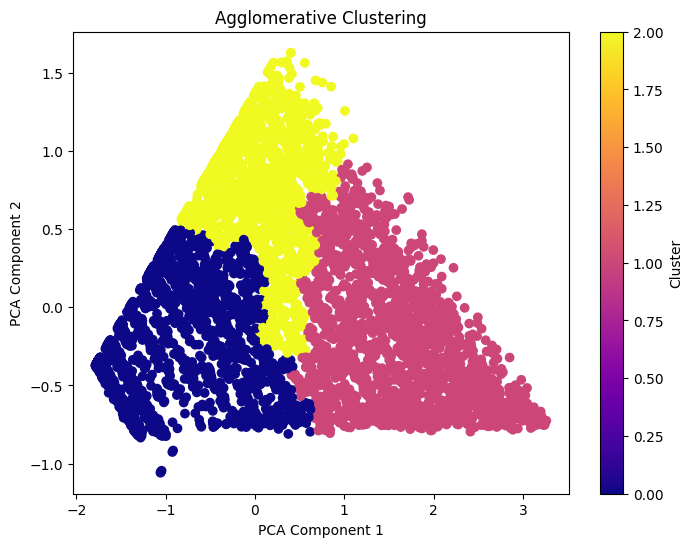

In [ ]:
# ------------------- Visualization -------------------
# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot Agglomerative Clustering results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_agg, cmap='plasma')
plt.title('Agglomerative Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

## 5. Evaluation

For unsupervised clustering, internal validation metrics like the Silhouette Score are typically used to assess the quality of the clusters. A higher Silhouette Score indicates better-defined clusters. It measures how similar an object is to its own cluster compared to other clusters.

It is important to note that directly comparing the unsupervised cluster labels (`clusters_agg`) with a predefined target variable like `Churn` (which is a binary classification label) using classification metrics (e.g., accuracy, precision, recall, F1-score, confusion matrix) is generally not appropriate for evaluating clustering performance. Clustering aims to find inherent groupings in the data, not necessarily to predict a specific pre-existing label. If the goal is to predict 'Churn', a supervised classification model would be more suitable, or a method to map clusters to churn classes would be required.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ... your existing code ...

# Convert 'Churn' column to numeric representation
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Calculate performance metrics
conf_matrix = confusion_matrix(df['Churn'], clusters_agg)
accuracy = accuracy_score(df['Churn'], clusters_agg)
precision = precision_score(df['Churn'], clusters_agg, average='weighted')
recall = recall_score(df['Churn'], clusters_agg, average='weighted')
f1 = f1_score(df['Churn'], clusters_agg, average='weighted')

# Print the metrics
print(f"Confusion Matrix:\n {conf_matrix}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Confusion Matrix:
 [[2612 1710  852]
 [ 512  396  961]
 [   0    0    0]]
Accuracy: 0.43
Precision: 0.66
Recall: 0.43
F1-Score: 0.52


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# The Silhouette Score was already calculated during the clustering step.
# We will re-print it here for clarity in the evaluation section.

# Ensure `silhouette_avg_agg` from cell 'q-wpq9EGqEeD' is available
# If running this cell independently, you might need to re-run the clustering cell first.

print(f"Agglomerative Clustering Silhouette Score: {silhouette_avg_agg:.2f}")

print("\nNote: Classification metrics (like accuracy, precision, recall, F1-score) are not directly applicable to evaluate unsupervised clustering against a target variable like 'Churn' without further steps (e.g., mapping clusters to known classes).")